# 03 · Gold-label correctness ($\mathcal{F}_2(\mathcal{D})$)

Are the benchmark *answers* right? We flag suspect gold labels by majority vote
across model predictions, then audit a sample with **search-grounded** and
**direct** GPT-5.4 verifiers, and measure the impact of removing confirmed
mislabels on the rankings.


In [1]:
import nbtools as nb
from nbtools import show_df, show_fig, show_md, run_mod, heavy, REGEN, REPORTS_DIR
print("SAYF_NB_REGEN =", REGEN, "  (heavy GPU/API steps run only when True)")
print("reports dir  :", REPORTS_DIR)

SAYF_NB_REGEN = False   (heavy GPU/API steps run only when True)
reports dir  : /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports


### Flag suspect labels — `analysis.gold_error_voting`
Threshold sweep + weighted / top-k / acceptance voting.

gold_error_voting: 19 votable tasks aggregated. Outputs in /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/{gold_errors,weighted_rank,topk,acceptance}/.
[gold_error_voting] recomputed live.


,task,n_samples,0.30,0.40,0.50,0.60,0.667,0.75,0.833,0.90,1.00
0,ate,55,1,1,1,0,0,0,0,0,0
1,vsp,995,405,238,150,89,63,35,6,5,0
2,ckt,3000,1850,1445,672,209,58,8,2,1,0
3,rms,500,206,114,47,7,0,0,0,0,0
4,mcq,2495,853,575,235,66,6,1,0,0,0
5,athena_ate,500,326,250,180,126,70,32,12,12,2
6,athena_vsp,2000,905,439,230,103,65,21,7,5,0
7,secure_maet,1067,81,64,45,28,16,8,2,2,0
8,secure_cwet,959,54,34,22,8,5,0,0,0,0
9,secure_kcv,461,45,44,43,37,32,25,20,18,11


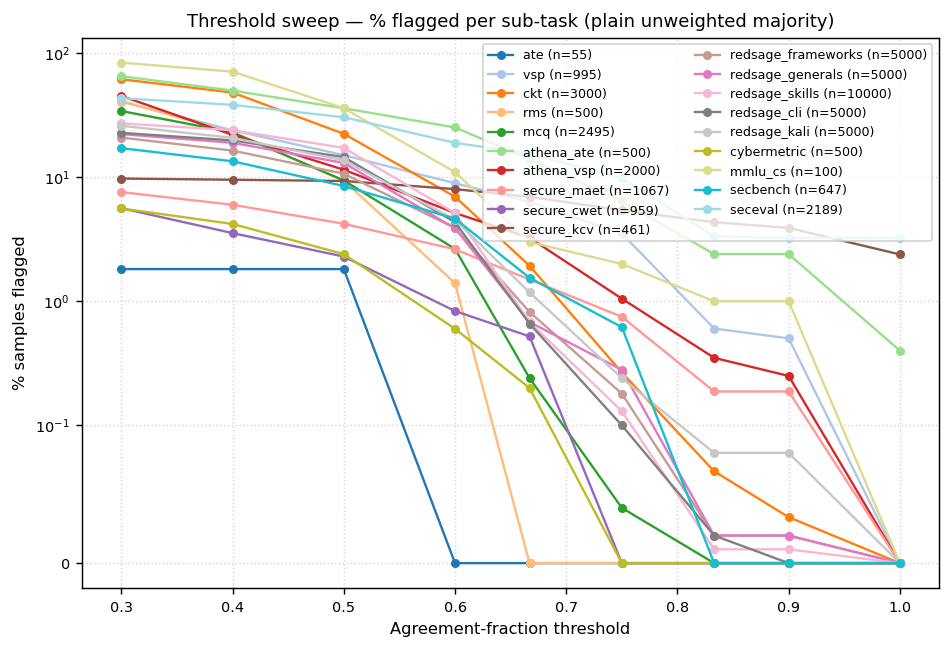

In [2]:
run_mod("gold_error_voting", "analysis.gold_error_voting")
show_df("gold_errors/threshold_sweep.csv")
show_fig("threshold_sweep.png")

### Build the verification bank — `analysis.build_verification_bank`

In [3]:
run_mod("build_verification_bank", "analysis.build_verification_bank")

  [WARN] gold mismatch at ckt/5: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/45: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/495: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/624: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/785: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/1442: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/1841: responses=frozenset({'E'}) flagged=frozenset() -- question/gold indices may be misaligned
  [WARN] gold mismatch at ckt/2505: responses=frozenset({'Ａ'}) flagged=frozenset() -- question/gold indices may be misaligned


  [WARN] gold mismatch at seceval/1181: responses=frozenset({'AA'}) flagged=frozenset({'A'}) -- question/gold indices may be misaligned


flagged bank: 6718 samples → /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/verification/flagged_bank.jsonl
  >= 1.0000: 84 samples
  >= 0.9000: 122 samples
  >= 0.8333: 130 samples
  >= 0.7500: 405 samples
  >= 0.5000: 6718 samples
[build_verification_bank] recomputed live.


True

### Verify flagged labels — `analysis.verify`  *(heavy · Azure API)*
Off by default — rendered from cached verdicts. Set `SAYF_NB_REGEN=1` (and an
Azure key) to re-run the search + direct verifier agents.


In [4]:
if heavy("verify"):
    run_mod("verify", "analysis.verify")
show_df("verification/per_threshold_search.csv")
show_md("verification/summary.md")

[verify] heavy step skipped — rendering cached artifact. Set SAYF_NB_REGEN=1 to recompute (needs GPU/API key).


,threshold,n_flagged,n_verified,gold_correct,majority_correct,both_wrong,uncertain,pending,fp_rate_verified
0,1.000,84,84,49,23,2,10,0,0.5833
1,0.900,122,122,60,39,2,21,0,0.4918
2,0.833,130,130,63,43,2,22,0,0.4846
3,0.750,405,405,201,122,7,75,0,0.4963
4,0.500,6718,1140,767,258,20,95,5578,0.6728


# Verification summary

Two GPT-5.4 verifiers were run over the flagged-sample bank.
`search` is grounded with the Azure web-search tool restricted to a tier-1/2 cybersec whitelist; `direct` uses model knowledge alone.

## Per-threshold breakdown

### Agent: search

| threshold | n_flagged | n_verified | gold_correct (FP) | majority_correct (TP) | both_wrong | uncertain | pending | FP-rate (verified) |
|---|---|---|---|---|---|---|---|---|
| 1.000 | 84 | 84 | 49 | 23 | 2 | 10 | 0 | 0.5833 |
| 0.900 | 122 | 122 | 60 | 39 | 2 | 21 | 0 | 0.4918 |
| 0.833 | 130 | 130 | 63 | 43 | 2 | 22 | 0 | 0.4846 |
| 0.750 | 405 | 405 | 201 | 122 | 7 | 75 | 0 | 0.4963 |
| 0.500 | 6718 | 1140 | 767 | 258 | 20 | 95 | 5578 | 0.6728 |

### Agent: direct

| threshold | n_flagged | n_verified | gold_correct (FP) | majority_correct (TP) | both_wrong | uncertain | pending | FP-rate (verified) |
|---|---|---|---|---|---|---|---|---|
| 1.000 | 84 | 84 | 64 | 18 | 2 | 0 | 0 | 0.7619 |
| 0.900 | 122 | 122 | 65 | 55 | 2 | 0 | 0 | 0.5328 |
| 0.833 | 130 | 130 | 65 | 63 | 2 | 0 | 0 | 0.5 |
| 0.750 | 405 | 405 | 195 | 199 | 7 | 4 | 0 | 0.4815 |
| 0.500 | 6718 | 405 | 195 | 199 | 7 | 4 | 6313 | 0.4815 |

## Search vs direct agreement

common verified samples: **405**, identical verdicts: **233** (57.5%)

| | gold_correct | majority_correct | both_wrong | uncertain |
|---|---|---|---|---|
| search=gold_correct | 139 | 55 | 3 | 4 |
| search=majority_correct | 26 | 94 | 2 | 0 |
| search=both_wrong | 3 | 4 | 0 | 0 |
| search=uncertain | 27 | 46 | 2 | 0 |


### Aggregate verdicts + figures — `aggregate_verification`, `make_verify_plots`, `make_fp_threshold_plot`

wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/verification/per_threshold_*.csv + summary.md + agreement.csv
[aggregate_verification] recomputed live.


figures written to /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/figures/
[make_verify_plots] recomputed live.


wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/figures/fp_threshold_combined.png
[make_fp_threshold_plot] recomputed live.


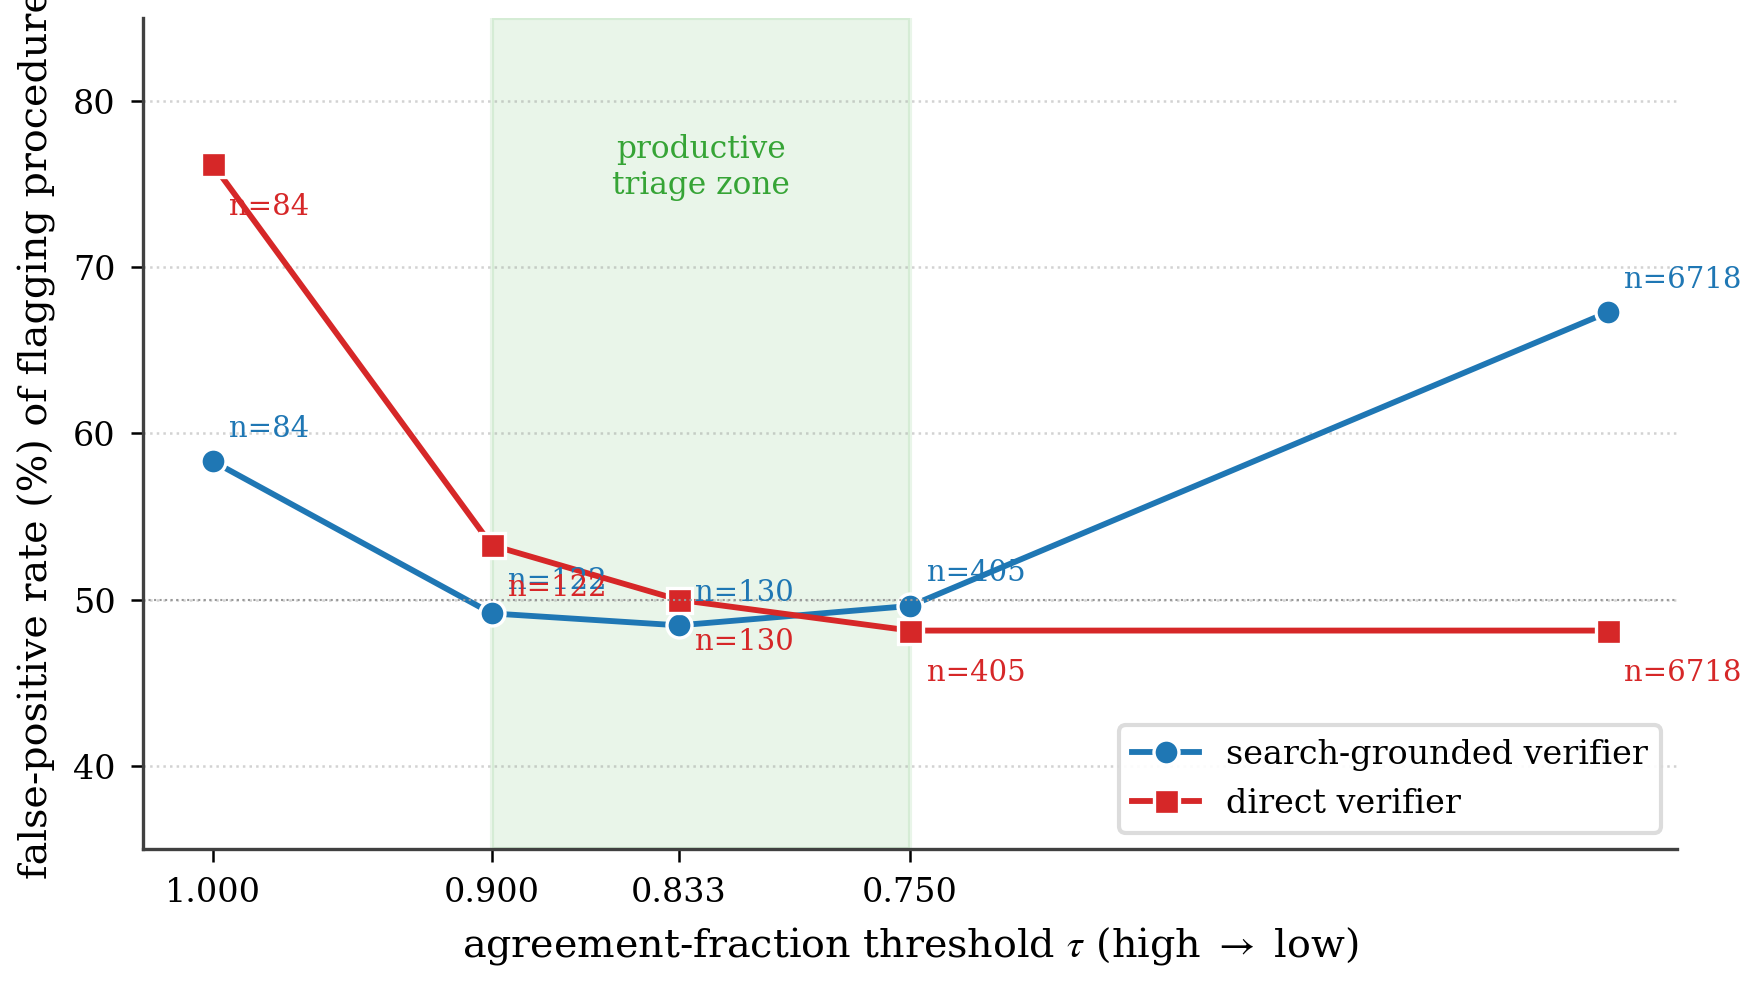

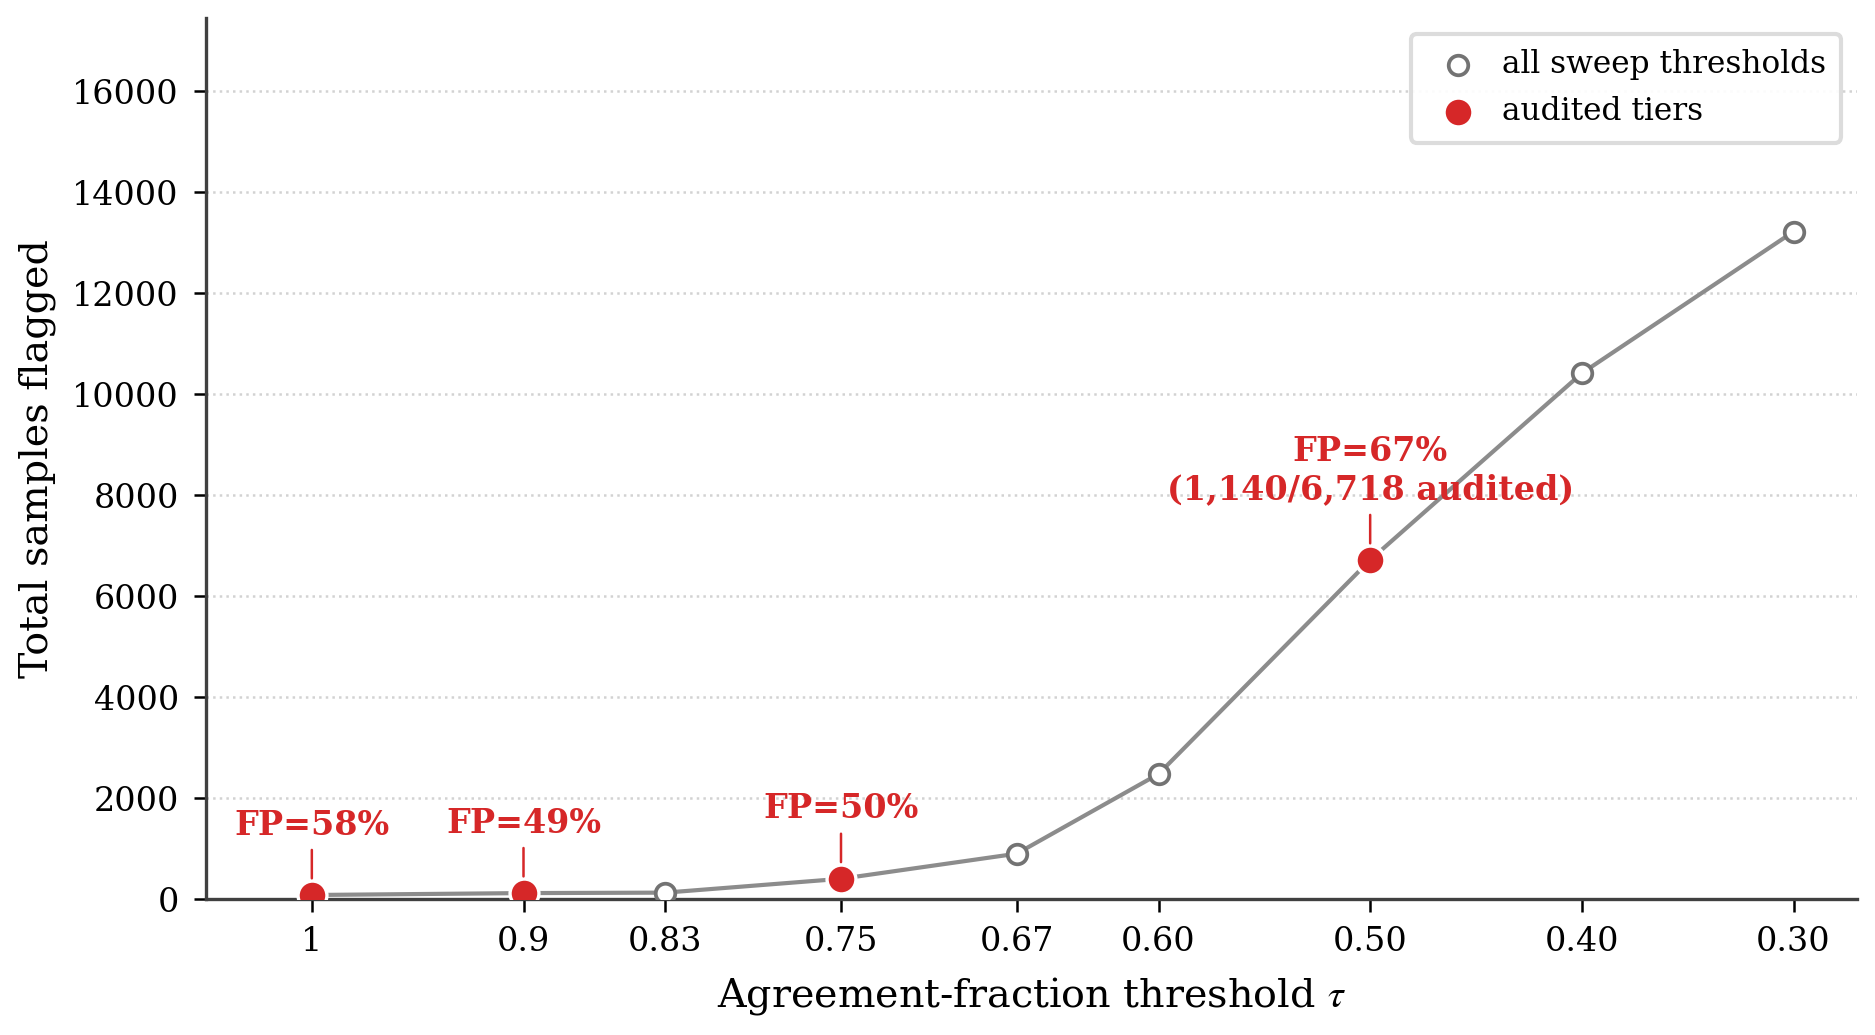

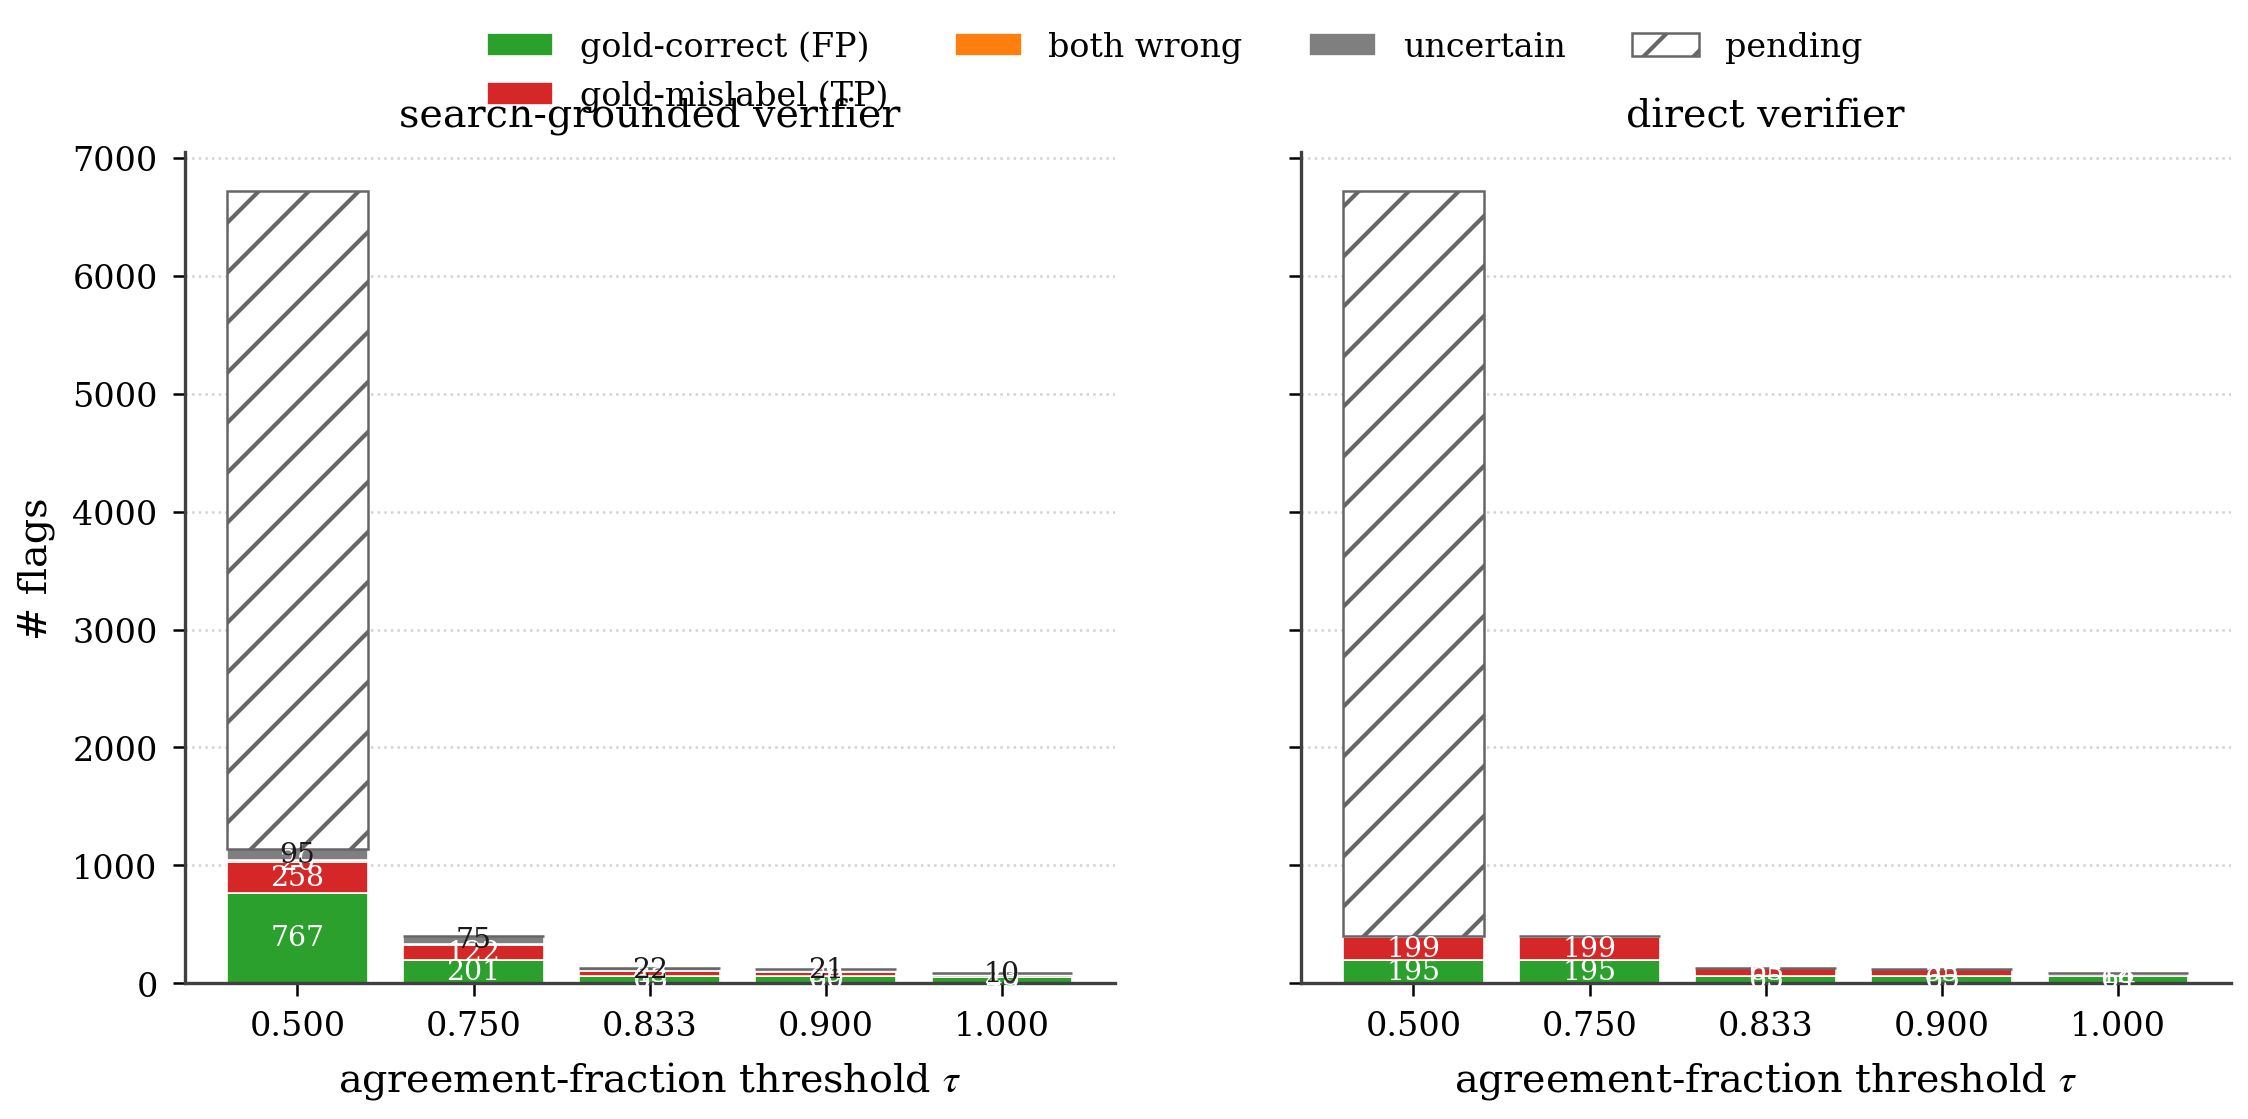

In [5]:
run_mod("aggregate_verification", "analysis.aggregate_verification")
run_mod("make_verify_plots", "analysis.make_verify_plots")
run_mod("make_fp_threshold_plot", "analysis.make_fp_threshold_plot")
show_fig("fp_vs_threshold.png")
show_fig("fp_threshold_combined.png")
show_fig("verdict_breakdown.png")

### Impact on rankings — `analysis.label_quality_impact`
Recompute accuracy excluding confirmed-mislabel samples; compare rankings.

In [6]:
run_mod("label_quality_impact", "analysis.label_quality_impact")
show_df("label_quality_impact/delta_table.csv")
show_md("label_quality_impact/ranking_diff.md")

Loaded 405 verified samples; 210 flagged to exclude (verdicts: {'uncertain', 'majority_correct', 'both_wrong'}).
Per-task exclusions:
  seceval                33
  vsp                    31
  athena_ate             30
  secure_kcv             25
  athena_vsp             19
  redsage_generals       14
  redsage_kali           12
  redsage_skills         12
  redsage_frameworks     9
  secure_maet            8
  ckt                    5
  redsage_cli            5
  secbench               4
  mmlu_cs                2
  mcq                    1



Wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/label_quality_impact/{results_table_filtered.csv, delta_table.csv, ranking_diff.md, excluded_samples.csv}

Baseline ranking:  ['claude-sonnet-4-6-cyberxpert', 'GPT-5.4', 'Gemma-4-31B-it', 'Qwen3.6-35B-A3B', 'Llama-Primus-Nemotron-70B-Instruct', 'RedSage-Qwen3-8B-DPO', 'Llama-3.3-70B-Instruct', 'GPT-oss-20B', 'Foundation-Sec-8B-Instruct', 'Llama-Primus-Merged']
Filtered ranking:  ['claude-sonnet-4-6-cyberxpert', 'GPT-5.4', 'Gemma-4-31B-it', 'Qwen3.6-35B-A3B', 'Llama-Primus-Nemotron-70B-Instruct', 'RedSage-Qwen3-8B-DPO', 'Llama-3.3-70B-Instruct', 'GPT-oss-20B', 'Foundation-Sec-8B-Instruct', 'Llama-Primus-Merged']
[label_quality_impact] recomputed live.


,model,avg_baseline,avg_filtered,delta_pct_pts,rank_baseline,rank_filtered,rank_change
0,GPT-5.4,72.69,73.03,0.34,2,2,0
1,Llama-3.3-70B-Instruct,61.55,61.75,0.20,7,7,0
2,Llama-Primus-Nemotron-70B-Instruct,63.46,63.76,0.30,5,5,0
3,Gemma-4-31B-it,68.18,68.46,0.28,3,3,0
4,Qwen3.6-35B-A3B,64.18,64.43,0.25,4,4,0
5,GPT-oss-20B,59.15,59.27,0.12,8,8,0
6,Foundation-Sec-8B-Instruct,56.32,56.48,0.16,9,9,0
7,Llama-Primus-Merged,53.63,53.79,0.16,10,10,0
8,RedSage-Qwen3-8B-DPO,63.07,63.29,0.22,6,6,0
9,claude-sonnet-4-6-cyberxpert,75.22,75.56,0.33,1,1,0


# Label-quality impact on the master ranking

Excluded **210 samples** (verdicts ['both_wrong', 'majority_correct', 'uncertain'] from the GPT-5.4 direct verifier at $\tau=0.75$) and recomputed per-(model, task) accuracy by skipping those (task, index) pairs in `*_detailed.jsonl`.

## Per-task exclusion counts

| Task | Excluded |
|---|---|
| seceval | 33 |
| vsp | 31 |
| athena_ate | 30 |
| secure_kcv | 25 |
| athena_vsp | 19 |
| redsage_generals | 14 |
| redsage_kali | 12 |
| redsage_skills | 12 |
| redsage_frameworks | 9 |
| secure_maet | 8 |
| ckt | 5 |
| redsage_cli | 5 |
| secbench | 4 |
| mmlu_cs | 2 |
| mcq | 1 |

## Ranking — before vs after

| Rank | Baseline (full) | Filtered (exclude wrong+uncertain) |
|---|---|---|
| 1 | claude-sonnet-4-6-cyberxpert (75.22) | claude-sonnet-4-6-cyberxpert (75.56) |
| 2 | GPT-5.4 (72.69) | GPT-5.4 (73.03) |
| 3 | Gemma-4-31B-it (68.18) | Gemma-4-31B-it (68.46) |
| 4 | Qwen3.6-35B-A3B (64.18) | Qwen3.6-35B-A3B (64.43) |
| 5 | Llama-Primus-Nemotron-70B-Instruct (63.46) | Llama-Primus-Nemotron-70B-Instruct (63.76) |
| 6 | RedSage-Qwen3-8B-DPO (63.07) | RedSage-Qwen3-8B-DPO (63.29) |
| 7 | Llama-3.3-70B-Instruct (61.55) | Llama-3.3-70B-Instruct (61.75) |
| 8 | GPT-oss-20B (59.15) | GPT-oss-20B (59.27) |
| 9 | Foundation-Sec-8B-Instruct (56.32) | Foundation-Sec-8B-Instruct (56.48) |
| 10 | Llama-Primus-Merged (53.63) | Llama-Primus-Merged (53.79) |

## Per-model deltas (sorted by |Δ|)

| Model | Baseline avg (\%) | Filtered avg (\%) | Δ (pp) | Rank baseline → filtered |
|---|---|---|---|---|
| GPT-5.4 | 72.69 | 73.03 | +0.34 | 2 → 2 (—) |
| claude-sonnet-4-6-cyberxpert | 75.22 | 75.56 | +0.33 | 1 → 1 (—) |
| Llama-Primus-Nemotron-70B-Instruct | 63.46 | 63.76 | +0.30 | 5 → 5 (—) |
| Gemma-4-31B-it | 68.18 | 68.46 | +0.28 | 3 → 3 (—) |
| Qwen3.6-35B-A3B | 64.18 | 64.43 | +0.25 | 4 → 4 (—) |
| RedSage-Qwen3-8B-DPO | 63.07 | 63.29 | +0.22 | 6 → 6 (—) |
| Llama-3.3-70B-Instruct | 61.55 | 61.75 | +0.20 | 7 → 7 (—) |
| Llama-Primus-Merged | 53.63 | 53.79 | +0.16 | 10 → 10 (—) |
| Foundation-Sec-8B-Instruct | 56.32 | 56.48 | +0.16 | 9 → 9 (—) |
| GPT-oss-20B | 59.15 | 59.27 | +0.12 | 8 → 8 (—) |

## Per-cell sanity

Cells that gained the most accuracy after filtering (highest |Δ| at the cell level — these are the tasks where the removed samples were heavily biasing scores):

| Model | Task | Baseline | Filtered | Δ (pp) | n_dropped |
|---|---|---|---|---|---|
| Qwen3.6-35B-A3B | secure_kcv | 88.29 | 93.35 | +5.06 | 25 |
| GPT-5.4 | secure_kcv | 87.42 | 92.43 | +5.01 | 25 |
| Llama-Primus-Nemotron-70B-Instruct | secure_kcv | 83.08 | 87.84 | +4.76 | 25 |
| claude-sonnet-4-6-cyberxpert | secure_kcv | 86.98 | 91.74 | +4.76 | 25 |
| Llama-3.3-70B-Instruct | secure_kcv | 81.78 | 86.24 | +4.46 | 25 |
| Llama-Primus-Merged | secure_kcv | 81.13 | 85.32 | +4.19 | 25 |
| Gemma-4-31B-it | secure_kcv | 70.50 | 74.54 | +4.04 | 25 |
| Foundation-Sec-8B-Instruct | secure_kcv | 80.04 | 83.94 | +3.90 | 25 |
| RedSage-Qwen3-8B-DPO | secure_kcv | 80.48 | 84.17 | +3.70 | 25 |
| Llama-3.3-70B-Instruct | athena_ate | 29.40 | 26.17 | -3.23 | 30 |
| Foundation-Sec-8B-Instruct | athena_ate | 38.00 | 35.11 | -2.89 | 30 |
| Llama-Primus-Merged | athena_ate | 33.60 | 30.85 | -2.75 | 30 |
| Qwen3.6-35B-A3B | athena_ate | 49.60 | 47.23 | -2.37 | 30 |
| GPT-oss-20B | athena_ate | 26.80 | 24.47 | -2.33 | 30 |
| Llama-Primus-Nemotron-70B-Instruct | athena_ate | 53.20 | 51.06 | -2.14 | 30 |


_Confirmed-label-error rate and the post-mitigation rank changes are the $\\mathcal{F}_2(\\mathcal{D})$ evidence._

### Human two-annotator label spot-check

To calibrate the automated verifier we drew a 50-item sample and had two
annotators independently judge whether they *agree* with each verifier verdict
(Cohen's κ + the adjudicated confirmation rate). This is the human validation the
label audit reports.


In [7]:
import pandas as pd
sp = pd.read_csv(REPORTS_DIR / "label_spotcheck/spotcheck.csv")
print("items:", len(sp), " verifier verdicts:", sp["verifier_verdict"].value_counts().to_dict())
if {"annotator_A", "annotator_B"}.issubset(sp.columns):
    both = sp[(sp["annotator_A"].astype(str).str.strip() != "") &
              (sp["annotator_B"].astype(str).str.strip() != "")]
    if len(both):
        print(f"human-annotated: {len(both)}/{len(sp)}  raw agreement: "
              f"{(both['annotator_A'] == both['annotator_B']).mean():.3f}")
    adj = sp.get("adjudicated")
    if adj is not None:
        adj = adj.astype(str).str.strip(); adj = adj[adj != ""]
        if len(adj):
            print("adjudicated:", adj.value_counts().to_dict())

items: 50  verifier verdicts: {'gold_correct': 38, 'majority_correct': 10, 'both_wrong': 1, 'uncertain': 1}
human-annotated: 50/50  raw agreement: 0.940
adjudicated: {'agree': 46, 'disagree': 2, 'unsure': 2}


Two annotators confirm the verifier on **46 of 50** verdicts (Cohen's κ≈0.68); the
four exceptions are two identified verifier errors and two items unverifiable from
the cited sources — the grounded-search verifier is right on the large majority of
the sample without being infallible.
